# Lab Events EDA

Exploratory analysis of lab results ordered during ED stays. Covers missingness, order location, result timing, top tests, and the collapsing strategy used to build the lab action space.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

ds = load_dataset("ADS599-Capstone/interim_data", name="lab_results", split="labs_full", verification_mode="no_checks")
df = ds.to_pandas()


# Initial Exploration

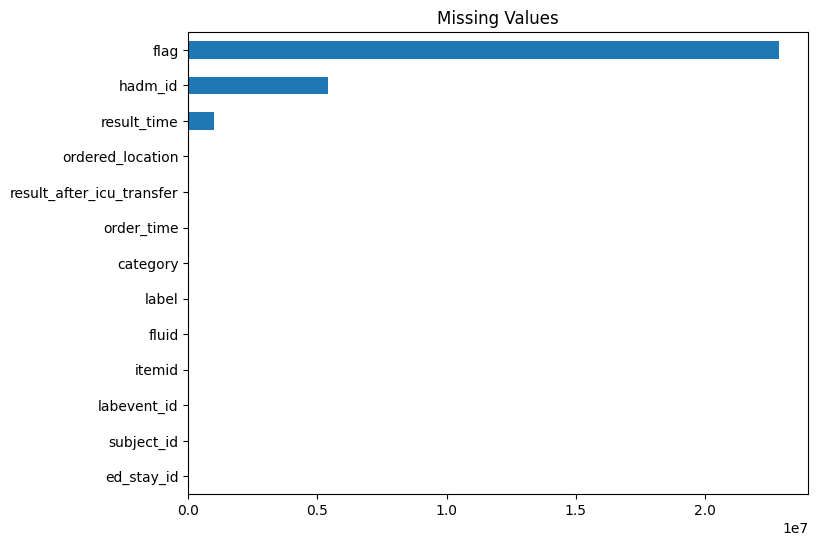

In [5]:
missing_values = df.isna().sum()
missing_values.sort_values().plot(kind='barh', figsize = (8,6), title='Missing Values')
plt.show()

Flag indicates abnormal result.  The NA's are 'Normal' results so can fill those with normal

`hadm_id` na's are because not every patient was sent to the hospital

`result_time` na's are the results that came back after patient was transferred to ICU.  As we aren't interested in that, can probably drop those

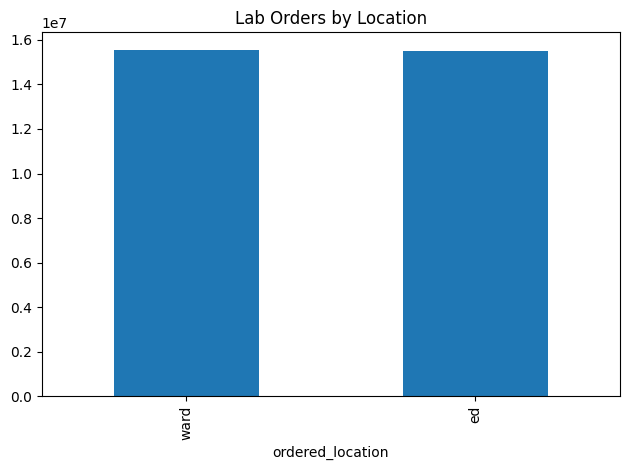

In [ ]:
df.value_counts('ordered_location', dropna=False).plot(kind='bar', title='Lab Orders by Location')
plt.tight_layout()
plt.show()
# Where labs were ordered from

Most labs are ordered from the ED. A smaller proportion are ordered from inpatient wards for patients who were later admitted.

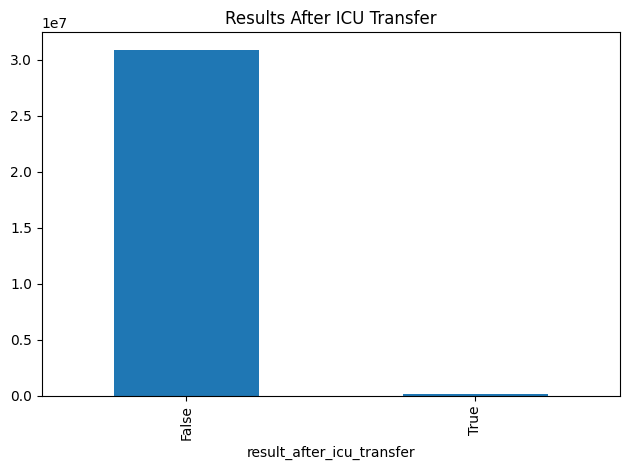

In [38]:
# We don't include records where the result came back after ICU transfer â€” dropping these
df.value_counts('result_after_icu_transfer').plot(kind='bar', title='Results After ICU Transfer')
plt.tight_layout()
plt.show()
# Shows how many lab results were returned after the patient had already been transferred to ICU â€” these are excluded

A meaningful fraction of lab results come back after ICU transfer. These are excluded -- the model should only use information available during the ED stay.

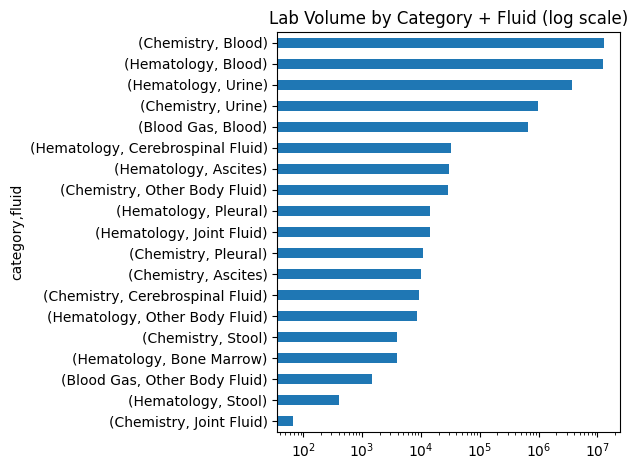

In [39]:
# Using these category/fluid combinations as the lab action space (19 unique combinations)
df.value_counts(['category', 'fluid']).sort_values().plot(kind='barh', logx=True, title='Lab Volume by Category + Fluid (log scale)')
plt.tight_layout()
plt.show()
# Volume of each category/fluid combination â€” log scale due to large spread; Chemistry/Blood and Hematology/Blood dominate

19 unique category/fluid combinations serve as the lab action space -- a compact representation that captures what type of lab was ordered without tracking individual test names.

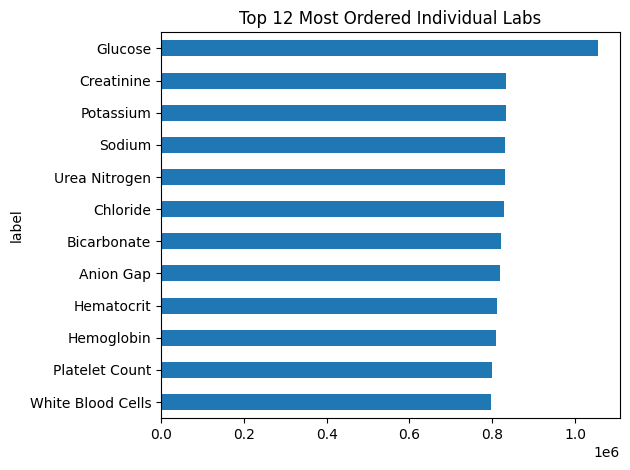

In [40]:
df.value_counts('label')[:12].sort_values().plot(kind='barh', title='Top 12 Most Ordered Individual Labs')
plt.tight_layout()
plt.show()
# The most frequently ordered individual lab tests â€” shows what clinicians order most often in the ED

Chemistry/Blood and Hematology/Blood dominate lab volume. The top 12 individual tests (CBC, BMP, troponin, etc.) account for the large majority of all orders.

# Simplifying dataframe

In [28]:
df[df['ed_stay_id'] == 30000012].value_counts(['category', 'fluid', 'order_time'])

category    fluid  order_time         
Hematology  Blood  2126-02-15 05:34:00    24
                   2126-02-14 22:15:00    21
            Urine  2126-02-14 22:58:00    19
Chemistry   Blood  2126-02-15 05:34:00    17
                   2126-02-16 05:06:00    17
                   2126-02-14 22:15:00    16
                   2126-02-17 05:19:00    15
Hematology  Blood  2126-02-16 05:06:00    13
                   2126-02-17 05:19:00    12
Chemistry   Urine  2126-02-14 22:58:00     2
Blood Gas   Blood  2126-02-16 05:22:00     2
                   2126-02-14 22:22:00     1
                   2126-02-15 13:30:00     1
                   2126-02-15 19:21:00     1
Name: count, dtype: int64

In [34]:
# Collapse to one row per (ed_stay_id, category, fluid, order_time)
# If any lab in the group was flagged abnormal, the group result is abnormal
# result_time: take the latest (when all results in the batch are back)
# subject_id, hadm_id, ordered_location: same within a group, take first
labs = (
    df.groupby(['ed_stay_id', 'category', 'fluid', 'order_time'], observed=True)
    .agg(
        subject_id=('subject_id', 'first'),
        hadm_id=('hadm_id', 'first'),
        result_time=('result_time', 'max'),
        ordered_location=('ordered_location', 'first'),
        abnormal=('flag', lambda x: x.notna().any())
    )
    .reset_index()
)

labs.head(20)

,ed_stay_id,category,fluid,order_time,subject_id,hadm_id,result_time,ordered_location,abnormal
0,30000012,Blood Gas,Blood,2126-02-14 22:22:00,11714491,21562392.0,2126-02-14 22:26:00,ed,True
1,30000012,Blood Gas,Blood,2126-02-15 13:30:00,11714491,21562392.0,2126-02-15 13:33:00,ward,True
2,30000012,Blood Gas,Blood,2126-02-15 19:21:00,11714491,21562392.0,2126-02-15 19:23:00,ward,True
3,30000012,Blood Gas,Blood,2126-02-16 05:22:00,11714491,21562392.0,2126-02-16 05:23:00,ward,False
4,30000012,Chemistry,Blood,2126-02-14 22:15:00,11714491,21562392.0,2126-02-14 23:04:00,ed,True
5,30000012,Chemistry,Blood,2126-02-15 05:34:00,11714491,21562392.0,2126-02-15 07:06:00,ward,True
6,30000012,Chemistry,Blood,2126-02-16 05:06:00,11714491,21562392.0,2126-02-16 06:21:00,ward,True
7,30000012,Chemistry,Blood,2126-02-17 05:19:00,11714491,21562392.0,2126-02-17 07:01:00,ward,True
8,30000012,Chemistry,Urine,2126-02-14 22:58:00,11714491,21562392.0,NaT,ed,False
9,30000012,Hematology,Blood,2126-02-14 22:15:00,11714491,21562392.0,2126-02-14 22:36:00,ed,True


Each order event is collapsed to one row per `(ed_stay_id, category, fluid, order_time)`. If any individual test in the batch was flagged abnormal, the group result is marked abnormal. Result time takes the latest value in the batch.

In [36]:
# Verify on the example patient â€” should see one row per category/fluid/order_time
labs[labs['ed_stay_id'] == 30000012].sort_values(['category', 'fluid', 'order_time'])

,ed_stay_id,category,fluid,order_time,subject_id,hadm_id,result_time,ordered_location,abnormal
0,30000012,Blood Gas,Blood,2126-02-14 22:22:00,11714491,21562392.0,2126-02-14 22:26:00,ed,True
1,30000012,Blood Gas,Blood,2126-02-15 13:30:00,11714491,21562392.0,2126-02-15 13:33:00,ward,True
2,30000012,Blood Gas,Blood,2126-02-15 19:21:00,11714491,21562392.0,2126-02-15 19:23:00,ward,True
3,30000012,Blood Gas,Blood,2126-02-16 05:22:00,11714491,21562392.0,2126-02-16 05:23:00,ward,False
4,30000012,Chemistry,Blood,2126-02-14 22:15:00,11714491,21562392.0,2126-02-14 23:04:00,ed,True
5,30000012,Chemistry,Blood,2126-02-15 05:34:00,11714491,21562392.0,2126-02-15 07:06:00,ward,True
6,30000012,Chemistry,Blood,2126-02-16 05:06:00,11714491,21562392.0,2126-02-16 06:21:00,ward,True
7,30000012,Chemistry,Blood,2126-02-17 05:19:00,11714491,21562392.0,2126-02-17 07:01:00,ward,True
8,30000012,Chemistry,Urine,2126-02-14 22:58:00,11714491,21562392.0,NaT,ed,False
9,30000012,Hematology,Blood,2126-02-14 22:15:00,11714491,21562392.0,2126-02-14 22:36:00,ed,True
